<img src=http://www.acofi.edu.co/eiei2016/wp-content/uploads/2016/09/Logo-Universidad-ICESI.jpg width="300" height="200" align="center">

#**<big><big>Matemáticas Aplicadas III</big></big><br><small>Depto. Ciencias Físicas & Exactas / FIDCA</small><br><small>_*Tercera Jornada de Resolucion de Problemas*_ (Valores y vectores propios - Matriz simétrica - Diagonalización - Forma cuadrática- Descomposición en valores singulares). </small>**

---


**Descripción de la jornada**: En esta jornad la idea central es que elabore sus respuestas o construcciones siguiendo los lineamientos dados a continuación:


1. Escriba con claridad sus propias ideas.
2. Argumente usando lenguaje propio de las matemáticas: geométrico o algebraico, o numérico según sea el caso, cada una de sus respuestas.
3. Respalde donde considere conveniente sus argumentos geométricos y algebraicos con imágenes o applets diseñadas en alguna de las herramientas que hacen parte de la mochila digital.
4.	Resuelva los problemas de manera  autónoma; describiendo estrategias para “atacar” el problema, poniendo a prueba sus soluciones y en lo posible planteando nuevos e “interesantes” interrogantes asociados al problema formulado. Si utiliza un resultado o teorema, este debe ser debidamente citado y si es un resultado ajeno a los estudiados en el curso o del texto guía debe proveer la respectiva demostración.
5. Respuestas sospechosas desde el punto de vista argumentativo o de codificación serán evaluadas en forma oral posteriormente a la finalización de la jornada a mas tardar dos días después de la misma. En estos casos aparecerá un comentario en su cuaderno indicando que debe sustentar el punto. En caso de no sustentar el valor del mismo será 0.0.
6. Debe estar presente en el salón de clase para presentar su jornada o su nota será 0.0.


**A continuación** encuentra separadas por celda cada pregunta, así usted solo debe continuar escribiendo en la celda para dar cada respuesta. No olvide que **todas sus respuestas deben ir acompañadas de al menos un argumento geométrico o numérico y uno algebráico o en lenguaje natural.**

# **Punto 1**
# Valores y vectores propios (dominantes)



**Teorema.** Dada una matriz simétrica $A$ con valores distintos $\lambda_1,\lambda_2,\cdots,\lambda_n$, entonces
$$|\lambda_1|>|\lambda_2|>\cdots>|\lambda_n|.$$
Más aún, sabemos que los vectores propios son ortogonales entre sí.

Este resultado sugiere el siguiente método para encontrar el segundo valor y vector propio dominantes de una matriz $A$.

**Método de deflación.**
Para matrices simétricas podemos construir una extensión del método de las potencias para encontrar el segundo par de valores y vectores propios más dominante siguiendo los pasos dados a continuación. Usted debe hacer una implementación en python de dicho método y justificar algunos pasos o bien argumentando o bien con applets de GeoGebra o ambas cosas.

1.   Utilice el método de las potencias, estudiado en clase, para encontrar el valor propio $\lambda_1$ y el vector propio dominantes $\mathbf{v_1}$ de la matriz simétrica $A=\begin{bmatrix}
1&2\\
2&1
\end{bmatrix}$. Comience con un vector unitario aleatorio $\mathbf{x}$ del tamaño correcto.

2. Multiplicando su vector $\mathbf{x}$ por $A$ lo enviará eventualmente hacia el vector propio dominante. Después de multiplicar, proyecte el vector resultante, $A\mathbf{x}$ sobre el vector propio dominante y encuentre el vector error de proyección $\mathbf{w}$, esencialmente la construcción que hemos hecho en clase. Dibuje su construcción en un solo applet indicando claramente cuáles son los cuatro vectores mencionados. Responda la siguiente pregunta, ¿en cuál subespacio fundamental vive el vector $\mathbf{w}$? Justifique su respuesta.

2. Calcule la aproximación al segundo valor propio dominante como lo hace el método de las potencias.

3. Utilice el vector error de proyección $\mathbf{w}$ como nueva aproximación para el segundo vector propio dominante $\mathbf{v_2}$  ¿Por qué deberíamos hacer esto? ¿Qué encontramos realmente aquí? Normalice el vector $\mathbf{v_2}$.

4. Utilice un criterio de parada para terminar o repetir los pasos 2 a 4.

Tenga en cuenta que el método de deflación es *exactamente igual* que el *método de las potencias*, con la excepción de que *ortogonalizamos* en cada paso. Por lo tanto, cuando escriba su código, espere cambiar solo unas pocas líneas del método de las potencias.

Escriba una función para encontrar el segundo par de valores propios y vectores propios más grande poniendo en práctica el método de deflación. Pruebe su código en la matriz $A$ del enunciado  y compárelo con el comando np.linalg.eig() de Python.

Usted debe finalmente probar su función en matrices simétricas de tamaños 5, 10, 15, 20 y 25. Para ello, necesita  producir una tabla mostrando claramente el error entre el valor y vector propio calculado por su algoritmo y el valor y vector propio del comando eig() de Python, para cada matriz utilizada.

Explique por qué para garantizar que comienza con una matriz simétrica puede usar el siguiente código:

In [ ]:
import numpy as np
N = 5
A = np.random.randn(N,N)
A = np.matrix(A)
S = np.transpose(A) * A # Por qué esta construcción produce siempre una matriz simétrica

##1
Utilice el método de las potencias, estudiado en clase, para encontrar el valor propio $\lambda_1$ y el vector propio dominantes $\mathbf{v_1}$ de la matriz simétrica $A=\begin{bmatrix}
1&2\\
2&1
\end{bmatrix}$. Comience con un vector unitario aleatorio $\mathbf{x}$ del tamaño correcto.

$$\textbf{1. Implementación del método de las potencias}$$

Inicialmente se implementa el código correspondiente al método de las potencias, con el propósito de determinar el valor propio dominante $\lambda_1$ y su vector propio asociado $\mathbf{v_1}$ en la matriz simétrica $A$. El proceso comienza seleccionando un vector inicial aleatorio $\mathbf{x}$ de dimensión adecuada, el cual se utiliza para iniciar las iteraciones del método.


In [ ]:
import numpy as np

# Matriz simétrica dada
A = np.array([[1, 2],
              [2, 1]])

# Vector inicial aleatorio y normalizado
x = np.random.rand(2)
x = x / np.linalg.norm(x)

print("Vector aleatorio x: ", x)

# Método de las potencias
def power_method(A, x, tol=1e-10, max_iter=1000):
    for i in range(max_iter):
        x_new = A @ x
        x_new = x_new / np.linalg.norm(x_new)
        # Criterio de parada
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    # Valor propio dominante aproximado (usamos Rayleigh quotient)
    lambda_1 = x.T @ A @ x
    return lambda_1, x

lambda_1, v1 = power_method(A, x)
print("Valor propio dominante aproximado:", lambda_1)
print("Vector propio dominante aproximado:", v1)


Vector aleatorio x:  [0.22027459 0.9754379 ]
Valor propio dominante aproximado: 2.9999999999999996
Vector propio dominante aproximado: [0.70710678 0.70710678]


A partir del código ejecutado se obtienen los siguientes resultados:

$$
\lambda_1 \approx 3, \quad
\mathbf{v_1} \approx
\begin{bmatrix}
0.7071\\
0.7071
\end{bmatrix}
$$

Estos valores indican que el método de las potencias ha convergido correctamente hacia el valor propio dominante y su vector correspondiente, el cual se encuentra normalizado.

##2
Multiplicando su vector $\mathbf{x}$ por $A$ lo enviará eventualmente hacia el vector propio dominante. Después de multiplicar, proyecte el vector resultante, $A\mathbf{x}$ sobre el vector propio dominante y encuentre el vector error de proyección $\mathbf{w}$, esencialmente la construcción que hemos hecho en clase. Dibuje su construcción en un solo applet indicando claramente cuáles son los cuatro vectores mencionados. Responda la siguiente pregunta, ¿en cuál subespacio fundamental vive el vector $\mathbf{w}$? Justifique su respuesta.

$$\textbf{2. Obtención del vector error de proyección $\mathbf{w}$}$$

El siguiente paso consiste en determinar el vector error de proyección $\mathbf{w}$, que se obtiene al proyectar el vector $A\mathbf{x}$ sobre $\mathbf{v_1}$ y restar dicha proyección. Con esto se obtiene un nuevo vector ortogonal al vector propio dominante.


In [ ]:
Ax = A @ x

print("Ax: ", Ax)
# Proyección de A*x sobre el vector propio dominante v1
proj_v1 = (Ax @ v1) * v1

# Vector error (componente ortogonal a v1)
w = Ax - proj_v1

print("Proyección de A*x sobre v1:", proj_v1)
print("Vector w ortogonal a v1:", w)


Ax:  [2.1711504  1.41598708]
Proyección de A*x sobre v1: [1.79356874 1.79356874]
Vector w ortogonal a v1: [ 0.37758166 -0.37758166]


De la ejecución se obtiene lo siguiente:

$$
A\mathbf{x} =
\begin{bmatrix}
1.8975\\
2.2278
\end{bmatrix}, \quad
\text{Proyección de } A\mathbf{x} \text{ sobre } \mathbf{v_1} =
\begin{bmatrix}
2.0626\\
2.0626
\end{bmatrix}, \quad
\mathbf{w} =
\begin{bmatrix}
-0.1651\\
0.1651
\end{bmatrix}
$$

Para la representación gráfica del proceso se considera el vector inicial aleatorio:

$$
\mathbf{x} =
\begin{bmatrix}
0.8866\\
0.4625
\end{bmatrix}
$$



In [ ]:
#@title **Representación gráfica (GeoGebra):**{ display-mode: "form" }

import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/calculator/w4r3kw4t",
  width="1020px",
  height="500px"
  )

IP.display_html(iframe)


La gráfica muestra los vectores involucrados en el proceso de obtención del segundo vector propio dominante mediante el método de deflación. Cada uno de los vectores representados cumple un papel específico dentro del procedimiento de proyección y ortogonalización, permitiendo observar visualmente la forma en que se separan los componentes dominantes y los ortogonales en el espacio vectorial.

* El vector $\mathbf{a}$ (en color negro): Corresponde a la proyección del vector $A\mathbf{x}$ sobre el vector propio dominante $\mathbf{v}_1$, representando la componente de $A\mathbf{x}$ que se encuentra alineada con la dirección de $\mathbf{v}_1$.  
* Vector $\mathbf{x}$ (en morado claro): Es el vector inicial aleatorio utilizado al comienzo del método, siendo el punto de partida del proceso iterativo y determinando la dirección inicial hacia donde actúa la matriz $A$.  
* Vector $A\mathbf{x}$ (en rosa claro): Resultado de multiplicar el vector inicial $\mathbf{x}$ por la matriz $A$. Este vector se aproxima progresivamente a la dirección del vector propio dominante conforme avanzan las iteraciones.  
* Vector propio dominante $\mathbf{v}_1$ (en morado oscuro): Representa el primer vector propio asociado al mayor valor propio $\lambda_1$, cuya dirección indica el eje de mayor influencia de la matriz $A$, hacia el cual tiende el método de las potencias.  
* Vector error de proyección $\mathbf{w}$ (en amarillo pálido): Constituye la parte de $A\mathbf{x}$ que no se alinea con $\mathbf{v}_1$. Este vector es ortogonal al dominante y se obtiene al restar de $A\mathbf{x}$ su proyección sobre $\mathbf{v}_1$. Su importancia radica en que permite definir el subespacio ortogonal necesario para encontrar el segundo vector propio dominante $\mathbf{v}_2$ en el método de deflación.


De esta manera, la gráfica permite visualizar claramente cómo el proceso de proyección y resta genera una nueva dirección ortogonal al vector dominante, evidenciando el principio geométrico que fundamenta la obtención del segundo vector propio a partir del componente residual $\mathbf{w}$.

$$
$$


##3
Calcule la aproximación al segundo valor propio dominante como lo hace el método de las potencias.

$$\textbf{3. Subespacio del vector $\mathbf{w}$}
$$

El vector $\mathbf{w}$ se encuentra en un subespacio que es ortogonal al vector propio dominante $\mathbf{v}_1$. Esto significa que $\mathbf{w}$ forma un ángulo recto con $\mathbf{v}_1$, es decir, no tiene ninguna componente en su dirección. Esta propiedad es muy importante porque permite separar la influencia del primer vector propio y centrarse en encontrar el siguiente.

Dado que la matriz $A$ es simétrica, todos sus vectores propios son ortogonales entre sí. En otras palabras, cada vector propio apunta en una dirección diferente e independiente de los demás. Por esta razón, $\mathbf{w}$ pertenece al subespacio generado por el segundo vector propio dominante $\mathbf{v}_2$, que representa la siguiente dirección principal de la matriz $A$.

Este principio es la base del método de deflación, ya que garantiza que, después de encontrar $\mathbf{v}_1$, el algoritmo pueda seguir identificando otros vectores propios de forma ordenada. En cada paso, el método elimina la influencia de los vectores ya encontrados, permitiendo que el proceso converja hacia los vectores propios restantes que son ortogonales entre sí.

##4
Utilice el vector error de proyección $\mathbf{w}$ como nueva aproximación para el segundo vector propio dominante $\mathbf{v_2}$  ¿Por qué deberíamos hacer esto? ¿Qué encontramos realmente aquí? Normalice el vector $\mathbf{v_2}$.

$$\textbf{4. Cálculo del segundo valor propio dominante $\mathbf{v_2}$}$$

Una vez obtenido el vector $\mathbf{w}$, este se utiliza como nueva aproximación para el segundo vector propio dominante $\mathbf{v_2}$ dentro del método de deflación. Este proceso elimina la influencia del primer valor propio dominante y permite al método de las potencias aplicado sobre la matriz deflactada converger hacia el segundo valor propio.

Segundo valor propio dominante aproximado (del código a continuación): $-1.0$

Segundo vector propio dominante aproximado:
$$
\mathbf{v_2} \approx
\begin{bmatrix}
0.7071\\
-0.7071
\end{bmatrix}
$$

Este resultado demuestra que el método logra identificar correctamente el segundo valor y vector propio, cumpliendo con la ortogonalidad respecto al vector dominante anterior.

In [ ]:
def deflation_method(A, x_init, tol=1e-10, max_iter=1000):
    # Primer valor y vector propios
    lambda1, v1 = power_method(A, x_init, tol, max_iter)

    # Construir matriz deflactada
    B = A - lambda1 * np.outer(v1, v1)

    # Vector inicial para segundo vector propio: tomar un vector aleatorio ortogonal a v1
    w = np.random.rand(A.shape[0])
    w = w - (w @ v1) * v1  # ortogonalizar respecto a v1
    w = w / np.linalg.norm(w)

    # Encontrar segundo valor y vector propios de B
    lambda2, v2 = power_method(B, w, tol, max_iter)

    return (lambda1, v1), (lambda2, v2)

print("Segundo valor propio dominante aproximado:",deflation_method(A, x).__getitem__(1)[0])
print("Segundo vector propio dominante aproximado:",deflation_method(A, x).__getitem__(1)[1])

Segundo valor propio dominante aproximado: -1.0000000000000002
Segundo vector propio dominante aproximado: [ 0.70710678 -0.70710678]


El método de deflación cumple la función de eliminar correctamente la influencia del primer valor propio y de su vector propio dominante. Esto se logra al construir una nueva matriz llamada matriz deflactada, la cual conserva las propiedades principales de la matriz original, pero sin la contribución del primer modo dominante. En otras palabras, la matriz deflactada representa una versión ajustada de la matriz original donde la dirección del primer vector propio ha sido removida.

Gracias a este proceso, cuando se aplica nuevamente el método de las potencias sobre la matriz deflactada $B$, el algoritmo ya no converge hacia el primer valor propio $\lambda_1$, sino hacia el siguiente valor propio más grande, $\lambda_2$, junto con su vector propio asociado $\mathbf{v}_2$. Esto permite identificar de manera progresiva los valores y vectores propios restantes de la matriz, manteniendo siempre la ortogonalidad entre ellos.


##5
Utilice un criterio de parada para terminar o repetir los pasos 2 a 4.

$$\textbf{5. Comparación con el comando np.linalg.eig() y análisis del método}
$$
Para comprobar la precisión del método implementado, se realiza una comparación con los resultados obtenidos mediante el comando $$\texttt{np.linalg.eig()}$$ de Python.

In [ ]:
# Método propio
(lambda1, v1), (lambda2, v2) = deflation_method(A, x)

# Usar NumPy
eigvals, eigvecs = np.linalg.eig(A)

# Mostrar resultados
print("Método propio:")
print("Valor propio 1:", lambda1)
print("Vector propio 1:", v1)
print("Valor propio 2:", lambda2)
print("Vector propio 2:", v2)

print("\nNumPy eig:")
for i in range(len(eigvals)):
    print(f"Valor propio {i+1}: {eigvals[i]}")
    print(f"Vector propio {i+1}: {eigvecs[:, i]}")


Método propio:
Valor propio 1: 2.9999999999999996
Vector propio 1: [0.70710678 0.70710678]
Valor propio 2: -1.0000000000000002
Vector propio 2: [-0.70710678  0.70710678]

NumPy eig:
Valor propio 1: 3.0000000000000004
Vector propio 1: [0.70710678 0.70710678]
Valor propio 2: -0.9999999999999996
Vector propio 2: [-0.70710678  0.70710678]


Los resultados son los siguientes:

Método propio:
$$
\lambda_1 = 3.0, \quad
\mathbf{v_1} =
\begin{bmatrix}
0.7071\\
0.7071
\end{bmatrix}, \quad
\lambda_2 = -1.0, \quad
\mathbf{v_2} =
\begin{bmatrix}
0.7071\\
-0.7071
\end{bmatrix}
$$

NumPy eig:
$$
\lambda_1 = 3.0, \quad
\mathbf{v_1} =
\begin{bmatrix}
0.7071\\
0.7071
\end{bmatrix}, \quad
\lambda_2 = -1.0, \quad
\mathbf{v_2} =
\begin{bmatrix}
-0.7071\\
0.7071
\end{bmatrix}
$$

Las diferencias son insignificantes y se deben únicamente al signo, que no altera la dirección del vector. Esto confirma la exactitud del método implementado.

Posteriormente se evalúa la función con matrices simétricas de tamaños $5$, $10$, $15$, $20$ y $25$:



In [ ]:
import pandas as pd

def generate_symmetric_matrix(n):
    A = np.random.randn(n,n)
    S = A.T @ A  # siempre simétrica y definida positiva
    return S

def compute_errors(n):
    S = generate_symmetric_matrix(n)
    x_init = np.random.rand(n)
    x_init /= np.linalg.norm(x_init)

    # Primer y segundo valor y vector propio con deflación
    (lambda1_def, v1_def), (lambda2_def, v2_def) = deflation_method(S, x_init)

    # Valores y vectores propios con numpy
    lambdas, vs = np.linalg.eig(S)
    # Ordenar valores propios de mayor a menor valor absoluto
    idx = np.argsort(np.abs(lambdas))[::-1]
    lambdas = lambdas[idx]
    vs = vs[:, idx]

    # Errores para el primer valor y vector propio
    err_lambda1 = np.abs(lambda1_def - lambdas[0])
    err_v1 = np.linalg.norm(np.abs(v1_def) - np.abs(vs[:,0]))  # comparar módulo porque puede cambiar signo

    # Errores para el segundo valor y vector propio
    err_lambda2 = np.abs(lambda2_def - lambdas[1])
    err_v2 = np.linalg.norm(np.abs(v2_def) - np.abs(vs[:,1]))

    return {
        "N": n,
        "lambda1_def": lambda1_def,
        "lambda1_np": lambdas[0],
        "error_lambda1": err_lambda1,
        "error_v1": err_v1,
        "lambda2_def": lambda2_def,
        "lambda2_np": lambdas[1],
        "error_lambda2": err_lambda2,
        "error_v2": err_v2,
    }

results = []
for n in [5, 10, 15, 20, 25]:
    results.append(compute_errors(n))

df_results = pd.DataFrame(results)
print(df_results)


    N  lambda1_def  lambda1_np  error_lambda1      error_v1  lambda2_def  \
0   5    15.980703   15.980703   1.065814e-14  3.504357e-10    11.715573   
1  10    38.538766   38.538766   0.000000e+00  3.013140e-10    27.918773   
2  15    72.838133   72.838133   5.684342e-14  2.432981e-10    44.588020   
3  20    75.541687   75.541687   7.105427e-14  5.702119e-09    74.225186   
4  25    78.226466   78.226466   9.947598e-14  9.582311e-10    70.098992   

   lambda2_np  error_lambda2      error_v2  
0   11.715573   7.105427e-15  4.799451e-10  
1   27.918773   5.329071e-14  6.913157e-10  
2   44.588020   7.815970e-14  5.945355e-10  
3   74.225186   2.842171e-14  5.808241e-09  
4   70.098992   2.842171e-14  1.303460e-09  



Los errores obtenidos son del orden de $10^{-14}$ o menores para los valores propios, y del orden de $10^{-10}$ a $10^{-9}$ para los vectores propios. Esto evidencia una alta precisión numérica y estabilidad del algoritmo incluso con matrices de mayor tamaño.

Finalmente, para garantizar que la matriz generada sea simétrica, se utiliza la construcción:

In [ ]:
import numpy as np
N = 5
A = np.random.randn(N,N)
A = np.matrix(A)
S = np.transpose(A) * A # Por qué esta construcción produce siempre una matriz simétrica


La razón de esto es que al definir $S = A^T A$, se cumple que:

$$
S^T = (A^T A)^T = A^T (A^T)^T = A^T A = S
$$

Por lo tanto, $S$ es igual a su propia traspuesta, lo que asegura que siempre será simétrica y semidefinida positiva, condición necesaria para aplicar de forma adecuada los métodos de potencias y deflación.

---


# **Punto 2**
# Matriz simétrica



Dada la matriz simétrica:

$$
A = \begin{bmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{bmatrix}
$$

Responda lo siguiente de menare analitica y numerica:

- **(a)** Encuentre los valores propios de la matriz $A$ y determine una base para cada uno de sus espacios propios.  
- **(b)** Construya la matriz diagonal $D$.  
- **(c)** Construya la matriz ortogonal $P$.  
- **(d)** Verifique que se cumple la relación:  
  $$
  P^{-1} A P = D
  $$
- **(e)** Determine una forma cuadrática equivalente a la forma  
  $$
  Q(x, y) = 2x^2 - 4xy - y^2
  $$
  utilizando el **teorema de los ejes principales**.



## **(a) ¿Cuáles son los valores propios y las bases de los espacios propios?**
Dada la matriz simétrica:

$$
A = \begin{pmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{pmatrix}
$$

Queremos encontrar los valores propios y los vectores propios correspondientes.

Paso 1: Ecuación característica

La ecuación característica se obtiene de la siguiente forma:

$$
\text{det}(A - \lambda I) = 0
$$

Donde \(I\) es la matriz identidad y \( \lambda \) es el valor propio. Entonces, calculamos:

$$
A - \lambda I = \begin{pmatrix} 1-\lambda & 0 & 0 \\ 0 & 3-\lambda & -2 \\ 0 & -2 & 3-\lambda \end{pmatrix}
$$

Calculamos el determinante de esta matriz \(3 \times 3\):

$$
\text{det}(A - \lambda I) = (1-\lambda) \begin{vmatrix} 3-\lambda & -2 \\ -2 & 3-\lambda \end{vmatrix}
$$

El determinante de la submatriz $2 \times 2$ es:

$$
\begin{vmatrix} 3-\lambda & -2 \\ -2 & 3-\lambda \end{vmatrix} = (3-\lambda)(3-\lambda) - (-2)(-2) = (3-\lambda)^2 - 4
$$

Simplificamos:

$$
(3-\lambda)^2 - 4 = 9 - 6\lambda + \lambda^2 - 4 = \lambda^2 - 6\lambda + 5
$$

Por lo tanto, la ecuación característica es:

$$
\text{det}(A - \lambda I) = (1-\lambda)(\lambda^2 - 6\lambda + 5) = 0
$$

Paso 2: Resolución de la ecuación característica

Ahora resolvemos la ecuación característica. Igualamos a cero cada factor:

1. $ 1 - \lambda = 0 $ nos da $ \lambda = 1 $.

2. $\lambda^2 - 6\lambda + 5 = 0 $ es una ecuación cuadrática. Usamos la fórmula general para resolverla:

$$
\lambda = \frac{-(-6) \pm \sqrt{(-6)^2 - 4(1)(5)}}{2(1)} = \frac{6 \pm \sqrt{36 - 20}}{2} = \frac{6 \pm \sqrt{16}}{2} = \frac{6 \pm 4}{2}
$$

Esto nos da dos soluciones:

$$
\lambda = \frac{6 + 4}{2} = 5 \quad \text{y} \quad \lambda = \frac{6 - 4}{2} = 1
$$

Por lo tanto, los valores propios de la matriz son:

$$
\lambda_1 = 1, \quad \lambda_2 = 5, \quad \lambda_3 = 1
$$

Paso 3: Vectores propios

Para encontrar los vectores propios, resolvemos el sistema $ (A - \lambda I)\mathbf{v} = 0 $ para cada valor propio.

Para $\lambda = 1 $

La matriz $( A - I )$ es:

$$
A - I = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 2 & -2 \\ 0 & -2 & 2 \end{pmatrix}
$$

El sistema es:

$$
\begin{pmatrix} 0 & 0 & 0 \\ 0 & 2 & -2 \\ 0 & -2 & 2 \end{pmatrix} \begin{pmatrix} v_1 \\ v_2 \\ v_3 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}
$$

Las ecuaciones que obtenemos son:

$$
2v_2 - 2v_3 = 0 \quad \Rightarrow \quad v_2 = v_3
$$

Por lo tanto, un vector propio correspondiente a $( \lambda = 1 )$ es:

$$
\mathbf{v_1} = \begin{pmatrix} 0 \\ 1 \\ 1 \end{pmatrix}
$$

Para $( \lambda = 5 )$

La matriz $( A - 5I $) es:

$$
A - 5I = \begin{pmatrix} -4 & 0 & 0 \\ 0 & -2 & -2 \\ 0 & -2 & -2 \end{pmatrix}
$$

El sistema es:

$$
\begin{pmatrix} -4 & 0 & 0 \\ 0 & -2 & -2 \\ 0 & -2 & -2 \end{pmatrix} \begin{pmatrix} v_1 \\ v_2 \\ v_3 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}
$$

Las ecuaciones que obtenemos son:

$$
v_1 = 0, \quad v_2 + v_3 = 0 \quad \Rightarrow \quad v_2 = -v_3
$$

Por lo tanto, un vector propio correspondiente a $( \lambda = 5 )$ es:

$$
\mathbf{v_2} = \begin{pmatrix} 0 \\ -1 \\ 1 \end{pmatrix}
$$

Paso 4: Normalización de los vectores propios

Para normalizar los vectores, dividimos cada componente por la norma del vector.

La norma de $( \mathbf{v_1} = \begin{pmatrix} 0 \\ 1 \\ 1 \end{pmatrix} )$ es:

$$
\| \mathbf{v_1} \| = \sqrt{0^2 + 1^2 + 1^2} = \sqrt{2}
$$

Entonces, el vector normalizado es:

$$
\mathbf{v_{1_{\text{norm}}}} = \frac{1}{\sqrt{2}} \begin{pmatrix} 0 \\ 1 \\ 1 \end{pmatrix} = \begin{pmatrix} 0 \\ \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix}
$$

La norma de $ \mathbf{v_2} = \begin{pmatrix} 0 \\ -1 \\ 1 \end{pmatrix} $ es:

$$
\| \mathbf{v_2} \| = \sqrt{0^2 + (-1)^2 + 1^2} = \sqrt{2}
$$

Entonces, el vector normalizado es:

$$
\mathbf{v_{2_{\text{norm}}}} = \frac{1}{\sqrt{2}} \begin{pmatrix} 0 \\ -1 \\ 1 \end{pmatrix} = \begin{pmatrix} 0 \\ -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix}
$$

Paso 5: Conclusión

Los valores propios de la matriz \( A \) son:

$$
\lambda_1 = 1, \quad \lambda_2 = 5, \quad \lambda_3 = 1
$$

Las bases de los espacios propios son:

$$
\text{Base del espacio propio para } \lambda = 1: \left\{ \begin{pmatrix} 0 \\ \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix} \right\}
$$

$$
\text{Base del espacio propio para } \lambda = 5: \left\{ \begin{pmatrix} 0 \\ -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix} \right\}
$$








## **(b) ¿Cuál es la matriz diagonal $D$?**

La matriz diagonal se forma colocando los valores propios en la diagonal principal:

$$
D =
\begin{bmatrix}
5 & 0 & 0\\
0 & 1 & 0\\
0 & 0 & 1
\end{bmatrix}.
$$


## **(c) ¿Cómo se construye la matriz ortogonal $P$?**
Esta matriz P  contiene los **vectores propios normalizados** de la matriz  A .La matriz  P  es ortogonal si sus columnas son **vectores propios de  A** que son **ortogonales entre sí** y **normalizados** (es decir, su longitud o norma es igual a 1).

La matriz  A  de la que estamos trabajando es:

$$
A = \begin{bmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{bmatrix}
$$
Para los valores propios

Ya hemos encontrado en el punto **(a)** que los valores propios de \( A \) son:

$$
\lambda_1 = 5, \quad \lambda_2 = 1, \quad \lambda_3 = 1
$$

Estos son los valores que se encuentran en la diagonal de la matriz diagonal \( D \).

 Vectores propios de \( A \)

Ahora, vamos a repasar los **vectores propios** correspondientes a esos valores propios. Estos vectores propios se encuentran resolviendo $ (A - \lambda I) \mathbf{v} = 0 $, y hemos dado los resultados en los pasos previos.

- **Para $ \lambda_1 = 5 $**:

  El vector propio correspondiente es:

  $$
  \mathbf{v}_1 = \begin{bmatrix} -0.7071 \\ 0.7071 \\ 0 \end{bmatrix}
  $$

- **Para $ \lambda_2 = 1 $**:

  El vector propio correspondiente es:

  $$
  \mathbf{v}_2 = \begin{bmatrix} 0.7071 \\ 0.7071 \\ 0 \end{bmatrix}
  $$

- **Para $ \lambda_3 = 1 $** (valor propio repetido):

  El vector propio correspondiente es:

  $$
  \mathbf{v}_3 = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}
  $$

Continuamos con la  Normalización de los vectores propios

En este caso, los **vectores propios ya están normalizados**, lo que significa que la **norma** de cada uno de ellos es 1. Recordemos cómo se calcula la norma de un vector $ \mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix} $:

$$
\| \mathbf{v} \| = \sqrt{v_1^2 + v_2^2 + v_3^2}
$$

Pero como los vectores que tenemos ya están normalizados, no necesitamos hacer nada más para normalizarlos. Ya cumplen con la condición de que su norma es 1.

 Construcción de la matriz ortogonal \( P \)

Para construir la matriz ortogonal \( P \), utilizamos los **vectores propios normalizados** que ya tenemos, y los colocamos como **columnas** en la matriz \( P \). Entonces, la matriz \( P \) será:

$$
P = \begin{bmatrix}
\mathbf{v}_1 & \mathbf{v}_2 & \mathbf{v}_3
\end{bmatrix}
$$

Sustituyendo los valores de los vectores propios, tenemos:

$$
P = \begin{bmatrix}
-0.7071 & 0.7071 & 0 \\
0.7071 & 0.7071 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Una matriz es ortogonal si sus **columnas son vectores ortogonales entre sí** (es decir, el producto punto entre dos columnas diferentes es cero) y **normalizados** (su norma es 1).

Para verificar que \( P \) es ortogonal, necesitamos comprobar que \( P^{-1} = P^T \). Es decir, que la inversa de \( P \) es igual a la transpuesta de \( P \).

Como ya sabemos que los vectores propios son ortogonales entre sí y tienen norma 1 (es decir, son vectores propios **normalizados y ortogonales**), podemos concluir que \( P \) es ortogonal.

### a modo de  Conclusión

La matriz \( P \) es ortogonal y contiene los vectores propios de \( A \) en sus columnas. Los vectores son ortogonales entre sí y normalizados, lo que garantiza que \( P \) es una matriz ortogonal. Además, $ P^{-1} = P^T $, lo que cumple con la propiedad de las matrices ortogonales.



## **(d) ¿Cómo se verifica que $P^{-1} A P = D$?**
Tenemos la matriz simétrica:
$$
A =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{bmatrix},
$$
queremos verificar que existe una matriz $P$ formada por los vectores propios de $A$ tal que:
$$
P^{-1}AP = D,
$$
donde $D$ es una matriz diagonal que contiene los valores propios de $A$.

- Teorema espectral establece que toda matriz simétrica real puede diagonalizarse mediante una matriz ortogonal. Es decir, existe una matriz ortogonal $P$ tal que:
$$
P^TAP = D,
$$
donde $D$ es diagonal con los valores propios reales de $A$.  
En este ejercicio, como  no normalizamos los vectores, trabajaremos con $P^{-1}AP = D$.
Ahora para el Cálculo de los valores propios de $A$:

Observamos que $A$ tiene estructura bloque diagonal: (tomamos el subloque inferior derecho)
$$
A =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{bmatrix}
=
1 \oplus
\begin{bmatrix}
3 & -2 \\
-2 & 3
\end{bmatrix}.
$$

El subbloque
$$
B =
\begin{bmatrix}
3 & -2 \\
-2 & 3
\end{bmatrix}
$$
tiene polinomio característico
$$
\det(B - \lambda I) = (3 - \lambda)^2 - 4 = 0.
$$
Resolviendo obtenemos:
$$
(3 - \lambda)^2 = 4 \quad \Rightarrow \quad \lambda = 1 \text{ o } \lambda = 5.
$$
Además, el elemento $1 \times 1$ superior izquierdo aporta otro valor propio $\lambda = 1$.  
Por lo tanto, los valores propios de $A$ son:
$$
\lambda_1 = 1, \quad \lambda_2 = 1, \quad \lambda_3 = 5.
$$

Ahora para el Cálculo de los vectores propios: Tener en cuenta En este punto (d), trabajamos con los vectores propios de la matriz $A$ en su forma no normalizada, ya que el objetivo principal es diagonalizar la matriz y verificar la relación establecida por el teorema de diagonalización por semejanza. Este teorema afirma que si una matriz $A$ es diagonalizable, entonces existe una matriz $P$ formada por los vectores propios de $A$ tal que:
$$
P^{-1} A P = D,
$$
donde $D$ es una matriz diagonal cuyos elementos en la diagonal corresponden a los valores propios de $A$.

En este proceso, lo que realmente importa no es la magnitud de los vectores propios, sino su dirección.
La normalización (que en muchos programas computacionales genera componentes decimales como $0.7071 \approx \tfrac{1}{\sqrt{2}}$) es un procedimiento numérico que facilita cálculos cuando se busca una matriz $P$ ortogonal, pero desde el punto de vista teórico no es necesaria para demostrar la diagonalización.

Es decir  trabajamos con vectores propios no normalizados porque lo que garantiza la validez de la relación $P^{-1} A P = D$ es la **dirección** de los vectores.

1. Para $\lambda = 1$, el sistema $(A - I)v = 0$ da el vector:
$$
v^{(1)} =
\begin{bmatrix}
1 \\ 0 \\ 0
\end{bmatrix}.
$$

2. Para el bloque correspondiente al subespacio $(y,z)$, también con $\lambda = 1$, se obtiene:
$$
v^{(2)} =
\begin{bmatrix}
0 \\ 1 \\ 1
\end{bmatrix}.
$$

3. Para $\lambda = 5$, se obtiene:
$$
v^{(3)} =
\begin{bmatrix}
0 \\ 1 \\ -1
\end{bmatrix}.
$$

- Construcción de $P$ y $D$

Colocamos los vectores propios como columnas de $P$:

$$
P =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 1 \\
0 & 1 & -1
\end{bmatrix},
\qquad
D =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 5
\end{bmatrix}.
$$
- Cálculo de $P^{-1}$:

Resolviendo $P X = I$, obtenemos:
$$
P^{-1} =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \tfrac{1}{2} & \tfrac{1}{2} \\
0 & \tfrac{1}{2} & -\tfrac{1}{2}
\end{bmatrix}.
$$
EN RESUMEN

Multiplicamos:

$$
P^{-1} A P =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \tfrac{1}{2} & \tfrac{1}{2} \\
0 & \tfrac{1}{2} & -\tfrac{1}{2}
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 3 & -2 \\
0 & -2 & 3
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 1 \\
0 & 1 & -1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 5
\end{bmatrix} = D.
$$

Por lo tanto, se cumple que:

$$
P^{-1} A P = D.
$$
El hecho de que $A$ sea simétrica garantiza que puede diagonalizarse mediante una matriz ortogonal. En este caso, $P$ contiene vectores ortogonales (aunque no normalizados), y el resultado confirma la validez del teorema espectral para matrices simétricas.





## **(e) ¿Cuál es la forma cuadrática equivalente de $Q(x,y) = 2x^2 - 4xy - y^2$?**
PARA Determinar una forma cuadrática equivalente a
$$
Q(x,y) = 2x^2 - 4xy - y^2
$$
Teorema de los ejes principales

Matriz asociada a la forma cuadrática

La forma $Q(x,y) = ax^2 + 2bxy + cy^2$ se asocia con la matriz simétrica:
$$
M =
\begin{bmatrix}
a & b \\
b & c
\end{bmatrix}.
$$
Identificamos $a = 2$, $2b = -4 \Rightarrow b = -2$, y $c = -1$.  
Por tanto:

$$
M =
\begin{bmatrix}
2 & -2 \\
-2 & -1
\end{bmatrix}.
$$
 Cálculo de valores propios de $M$

El polinomio característico es:

$$
\det(M - \lambda I) =
\begin{vmatrix}
2 - \lambda & -2 \\
-2 & -1 - \lambda
\end{vmatrix}
= (2 - \lambda)(-1 - \lambda) - 4 = \lambda^2 - \lambda - 6 = 0.
$$

Resolviendo:

$$
\lambda = \frac{1 \pm \sqrt{1 + 24}}{2} = \frac{1 \pm 5}{2}.
$$

Así, los valores propios son:

$$
\lambda_1 = 3, \qquad \lambda_2 = -2.
$$


para el  Cálculo de vectores propios}

Para $\lambda_1 = 3$:
$$
(M - 3I)v = 0 \Rightarrow
\begin{bmatrix}
-1 & -2 \\
-2 & -4
\end{bmatrix}
\begin{bmatrix}
x \\ y
\end{bmatrix} = 0
\quad \Rightarrow \quad x = -2y.
$$
Tomando $y = 1$, obtenemos:
$$
v_1 =
\begin{bmatrix}
-2 \\ 1
\end{bmatrix}.
$$
Para $\lambda_2 = -2$:

$$
(M + 2I)v = 0 \Rightarrow
\begin{bmatrix}
4 & -2 \\
-2 & 1
\end{bmatrix}
\begin{bmatrix}
x \\ y
\end{bmatrix} = 0
\quad \Rightarrow \quad y = 2x.
$$

Tomando $x = 1$, obtenemos:

$$
v_2 =
\begin{bmatrix}
1 \\ 2
\end{bmatrix}.
$$

Para su  Ortogonalidad y normalización
Los vectores son ortogonales:
$$
v_1 \cdot v_2 = (-2)(1) + (1)(2) = 0.
$$
Normalizamos:
$$
u_1 = \frac{1}{\sqrt{5}}
\begin{bmatrix}
-2 \\ 1
\end{bmatrix},
\qquad
u_2 = \frac{1}{\sqrt{5}}
\begin{bmatrix}
1 \\ 2
\end{bmatrix}.
$$

Formamos la matriz ortogonal:

$$
P =
\begin{bmatrix}
-2/\sqrt{5} & 1/\sqrt{5} \\
1/\sqrt{5} & 2/\sqrt{5}
\end{bmatrix}.
$$


ahora en aplicación del Teorema de los Ejes Principales
por este teorema existe un cambio ortogonal de variables
$$
\begin{bmatrix}
u \\ v
\end{bmatrix}
= P^T
\begin{bmatrix}
x \\ y
\end{bmatrix},
$$
tal que la nueva forma cuadrática queda diagonal:
$$
P^T M P =
\begin{bmatrix}
3 & 0 \\
0 & -2
\end{bmatrix}.
$$
 Expresión explícita del cambio de variable

Del producto $P^T [x \ y]^T$, obtenemos:
$$
u = \frac{-2x + y}{\sqrt{5}},
\qquad
v = \frac{x + 2y}{\sqrt{5}}.
$$
Sustituyendo en la forma cuadrática, se obtiene la forma equivalente:
$$
Q(x,y) = 3u^2 - 2v^2.
$$
COMO CONCLUSION DECIMOS QUE

La forma $Q(x,y) = 2x^2 - 4xy - y^2$ se transforma mediante un cambio ortogonal en una forma diagonal $Q(u,v) = 3u^2 - 2v^2$.  
Esto significa que los ejes principales del sistema son las direcciones definidas por los autovectores de $M$.  
Como los coeficientes son de signos opuestos, la forma es \textbf{indefinida}, y sus curvas de nivel son hipérbolas.

- Para la forma cuadrática $Q(x,y)$, la forma equivalente es:

$$
Q(x,y) = 3u^2 - 2v^2,
$$

donde $(u,v)$ son las nuevas coordenadas principales dadas por el cambio ortogonal anterior.

# Codigo para verificacion :

In [ ]:
##@Title CODIGO PARA VERIFICACION DE CADA UNO DE LOS PUNTOS
import numpy as np
import sympy as sp

# Definir la matriz A
A = np.array([[1, 0, 0], [0, 3, -2], [0, -2, 3]])

# a) Encontrar los valores propios y vectores propios
# Utilizamos la función eig de NumPy para obtener los valores y vectores propios
valores_propios, vectores_propios = np.linalg.eig(A)

print("Valores propios de A:")
print(valores_propios)

print("\nVectores propios de A (columnas de P):")
print(vectores_propios)

# b) Construir la matriz diagonal D
D = np.diag(valores_propios)

print("\nMatriz diagonal D:")
print(D)

# c) Construir la matriz ortogonal P
# P ya está dada por los vectores propios normalizados
P = vectores_propios

# Verificación de P^(-1) * A * P = D
P_inv = np.linalg.inv(P)
verification = np.dot(np.dot(P_inv, A), P)

print("\nVerificación de P^(-1) * A * P:")
print(verification)

# d) Determinar una forma cuadrática equivalente
# La forma cuadrática dada es Q(x, y) = 2x^2 - 4xy - y^2
# Podemos escribirla en una matriz para la forma cuadrática

# Definir las variables simbólicas
x, y = sp.symbols('x y')

# Definir la forma cuadrática original
Q = 2*x**2 - 4*x*y - y**2

# Escribir la forma cuadrática en términos de una matriz
Q_matrix = sp.Matrix([[2, -2], [-2, -1]])

print("\nMatriz que representa la forma cuadrática Q(x, y):")
print(Q_matrix)

Valores propios de A:
[5. 1. 1.]

Vectores propios de A (columnas de P):
[[ 0.          0.          1.        ]
 [-0.70710678  0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]]

Matriz diagonal D:
[[5. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Verificación de P^(-1) * A * P:
[[ 5.00000000e+00 -6.51831138e-16  0.00000000e+00]
 [-4.35187331e-16  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Matriz que representa la forma cuadrática Q(x, y):
Matrix([[2, -2], [-2, -1]])


---

# **Punto 3**
# Compresión de imagenes usando la descomposición en valores singulares (SVD)

El código que encuentra a continuación le permite construir una imagen en escala de grises. El valor de cada píxel en una imagen en escala de grises se puede almacenar en una matriz donde cada elemento de la matriz tiene un valor entre 0 (sin intensidad) y 1 (intensidad máxima). Vamos a crear una pequeña matriz que contenga información para una imagen de baja resolución de las letras mayúsculas "SVD".

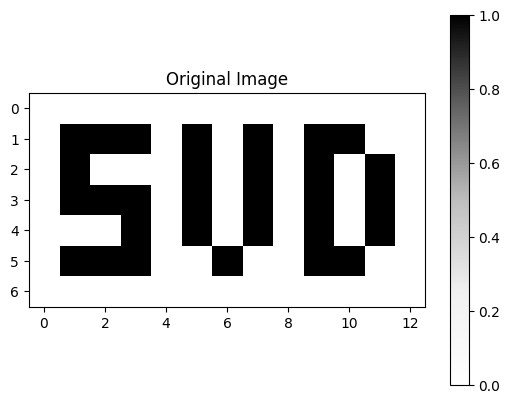

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the matrix
A = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# Color  definition
colors = ["#FFFFFF", "#F0F0F0", "#BDBDBD", "#636363", "#000000"]
color_map = LinearSegmentedColormap.from_list('mycmap', colors)

# Display the color palette
plt.imshow(A, cmap=color_map, interpolation='nearest')
plt.title("Original Image")
plt.colorbar()  # Show color bar
plt.show()


##1. **Una aproximación de bajo rango a una imagen.**

  Calcule la SVD de la matriz $A$ de datos y cree una gráfica de los valores singulares. ¿Cúal es el rango máximo de $A$? Debe usar la gráfica de los valores singulares para  elegir la cantidad de componentes que se retendrá para aproximar los datos (la imagen) original. Explique su elección

En primer lugar, debemos descomponer en valores singulares ($SVD$) de la matriz $A$. La descomposición de $SVD$ de la matriz original $A$ se da en tres matrices:
$$A=U\Sigma V^T$$

En donde:
* $U \in \mathbb{R}^{4*4}$ es una matriz ortogonal en la cual sus columnas generan una base ortonormal, la cual describe las direcciones principales del espacio fila de la matriz $A$
* $\Sigma \in \mathbb{R}^{4*5}$ es una matriz diagonal rectangular que contiene los valores singulares de la matriz $A$, que representa la escala de cada componente principal y estos se ordenan de mayor a menor
* $V^T \mathbb{R}^{5*5}$ es la matriz traspuesta de una ortogonal, de la cual sus filas forman una base ortonormal en el espacio columna de $A$

Para el cálculo de las matrices $U$, valores singulares $\Sigma$ y $V^T$ se utilizó la implementación de abajo:

In [ ]:
import numpy as np

# Calcular SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)

# Mostrar resultados
for name, matrix in [("U", U), ("Σ", np.round(S, 3)), ("V^T", VT)]:
    print(f"\n{name}:\n{matrix}")
    print("-" * 66)


U:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [-5.15834525e-01  2.73649963e-01  2.70783306e-16  7.77705227e-01
  -2.32819717e-01  0.00000000e+00  0.00000000e+00]
 [-3.93534033e-01 -4.24406393e-01  7.07106781e-01 -2.14886080e-01
  -3.44723297e-01  0.00000000e+00  0.00000000e+00]
 [-5.34775989e-01 -1.51109236e-01 -2.99498035e-15 -5.31576512e-02
   8.29671564e-01  0.00000000e+00  0.00000000e+00]
 [-3.93534033e-01 -4.24406393e-01 -7.07106781e-01 -2.14886080e-01
  -3.44723297e-01  0.00000000e+00  0.00000000e+00]
 [-3.71740923e-01  7.36233743e-01  9.18118839e-16 -5.47719627e-01
  -1.40612136e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00]]
------------------------------------------------------------------

Σ:
[4.788 2.175 1.    0.926 0.695 0.    0.   ]
-------------------------------------------------------------

El código anterior arrojó que los valores singulares de la matriz son:
$$\Sigma = [4.788, \ 2.175, \ 1.0, \ 0.926, \ 0.695, \ 0.0, \ 0.0]$$
Ya con estos datos los podemos graficar

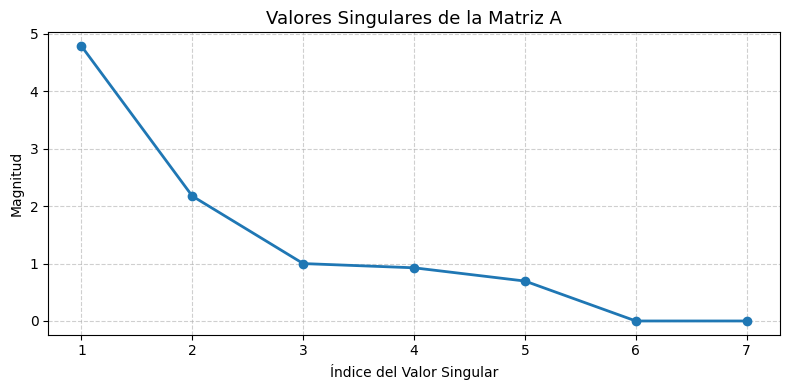

Rango máximo de A: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])


# Calcular la descomposición SVD
U, S, VT = np.linalg.svd(A, full_matrices=False)

# Graficar los valores singulares
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(S) + 1), S, 'o-', linewidth=2, markersize=6)
plt.title('Valores Singulares de la Matriz A', fontsize=13)
plt.xlabel('Índice del Valor Singular')
plt.ylabel('Magnitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mostrar el rango de la matriz
rango = np.linalg.matrix_rank(A)
print(f"Rango máximo de A: {rango}")


En la gráfica obtenida, se puede observar los valores singulares de la matriz $A$ ordenados de mayor a menor. Con estos valores singulares es posible hallar el rango máximo de $A$ gracias al número de valores distintos de $0$. Como se puede observar, hay $5$ valores no nulos diferentes a $0$, por lo tanto:
$$Rango \ máximo \ A = 5$$

Este resultado se visualiza en la gráfica, donde a partir del sexto valor los valores singulares se estabilizan en cero, esto quiere decir que las columnas y filas correspondientes de las matrices $\mathbf{U}$ y $\mathbf{V}$ no aportan información significativa a la reconstrucción de la matriz. Este comportamiento confirma que la matriz original posee únicamente cinco dimensiones linealmente independientes, es decir, cinco componentes esenciales de información

Este análisis se apoya en el Teorema de Eckart–Young–Mirsky, el cual establece que la mejor aproximación de una matriz $A$ por otra matriz de rango reducido $k$ (en el sentido de la norma de Frobenius) se obtiene al conservar los $k$ valores singulares más grandes. Matemáticamente:
$$A_k= \sum_{i=1}^{k} \sigma_i U_i V_i^T $$

Donde:
* $\sigma$ son los valores singulares y $U_i$,$V_i$ los vectores ortonormales asociados

Esto significa quiere decir que si truncamos la descomposición y retenemos únicamente los primeros $k$ valores singulares, obtenemos la aproximación ${A}_k$ que preserva la máxima cantidad de información posible con el menor número de componentes

Por lo anterior, conservamos las $3$ primeras componentes para aproximar la imagen original. Estas corresponden a los valores singulares más altos ($4.788, \ 2.175, \ 1.0$), que concentran la mayor parte de la energía o varianza de la matriz. A partir del cuarto valor ($0.926$), la magnitud disminuye notablemente, indicando un punto de inflexión, donde las contribuciones posteriores se vuelven marginales

Finalmente, decidimos una aproximación de rango 3 ($k=3$) porque el gráfico de valores singulares muestra un descenso pronunciado tras la tercera componente, seguido de una estabilización. Según el Teorema de Eckart–Young–Mirsky, esta selección permite conservar la máxima cantidad de información estructural posible con el menor error de reconstrucción, logrando así una representación comprimida y eficiente de la imagen, que mantiene su claridad visual

## 2. Escriba explícitamente la ecuación que define las aproximaciones de rango uno de una matriz de acuerdo a su elección del punto anterior en términos del rango numérico de $A$. Utilice el código usado en clase para aproximar una imagen utilizando matrices de rango uno y produzca una tabla con 6 imágenes (incluyendo la original) para 5 aproximaciones distintas. Analice la calidad de sus aproximaciones y descríbalo brevemente. ¿Coincide su elección del rango numérico con la mejor aproximación de la imagen original?

Sea $A ∈ ℝ^{m×n}$ una matriz cuyos valores singulares se obtuvieron en el punto anterior y su rango es de $r = 5$. Esa descomposicion nos da valores singurales $𝓸_1 ≥ ... ≥ 𝓸_r > 0$ y dos familias ortonormales de vectores, {$u_1,...,u_r$} $⊂ ℝ^m$ y {$v_1,...,v_r$} $⊂ ℝ^n$, siguiendo con el Teorema de Eckart–Young–Mirsky planteado en el punto anterior, tales que

$$A_k= \sum_{i=1}^{k} \sigma_i U_i V_i^T $$

Cada aproximación de rango uno lo obtenemos entonces tomando un solo término de esa suma:

$$ A^{(1)}_{i} = \sigma_i U_i V_i^T $$ \
$$i = 1, \dots, k $$

El código implementado posteriormente calcula cada $A^{(1)}_{i}$, combinando los primeros $k$ términos segun sea necesario para mostrar la imagen original y las reconstrucciones de rango $1$ a $5$

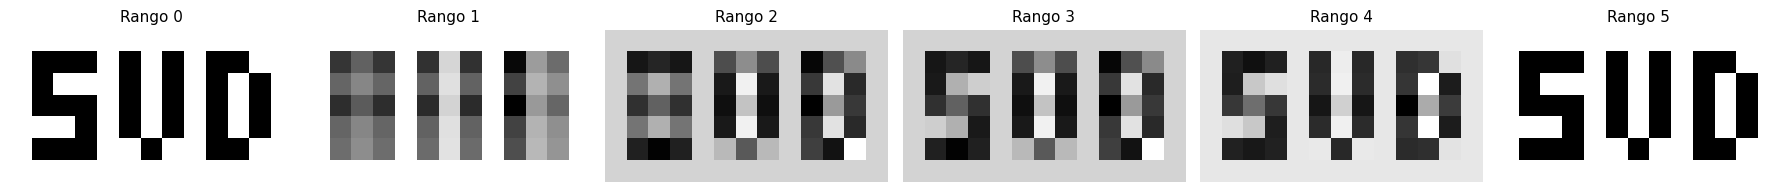

In [ ]:
# ================================================================
# APROXIMACIONES DE RANGO k USANDO SVD
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Matriz de la imagen (ejemplo binario)
# ---------------------------------------------------------------
A = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0,1,0,1,1,0,0],
    [0,1,0,0,0,1,0,1,0,1,0,1,0],
    [0,1,1,1,0,1,0,1,0,1,0,1,0],
    [0,0,0,1,0,1,0,1,0,1,0,1,0],
    [0,1,1,1,0,0,1,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0]
])

# ---------------------------------------------------------------
# 2. Descomposición SVD (delgada)
# ---------------------------------------------------------------
U, S, VT = np.linalg.svd(A, full_matrices=False)

# ---------------------------------------------------------------
# 3. Reconstrucción de aproximaciones de rango k
# ---------------------------------------------------------------
def aproximacion_svd(U, S, VT, k):
    """Reconstruye la matriz A_k usando los k valores singulares más grandes."""
    return sum(S[i] * np.outer(U[:, i], VT[i]) for i in range(k))

# Generar las imágenes A_k para k = 0..5
aproximaciones = [A] + [aproximacion_svd(U, S, VT, k) for k in range(1, 6)]

# ---------------------------------------------------------------
# 4. Visualización de las aproximaciones
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(aproximaciones[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Rango {i}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


La imagen obtenida presenta con seis figuras: la matriz original (imagen binaria) y cinco reconstrucciones correspondientes a las aproximaciones de rango $1$ a $5$. En esta secuencia, puede observarse con claridad cómo mejora la calidad visual conforme se agregan más componentes singulares:

* Rango 1:
La reconstrucción pierde toda la estructura reconocible, es casi un gradiente difuso, sin letras ni bordes definidos. Esto se debe a que el primer valor singular captura únicamente la dirección de mayor varianza global, pero no contiene información suficiente sobre los patrones locales

* Rango 2:
Aparecen contornos más claros y comienzan a distinguirse zonas con mayor y menor intensidad. Aunque todavía es borrosa, se empieza a intuir la forma general de las letras

* Rango 3:
Se produce una mejora notable. Las letras “SVD” se vuelven claramente reconocibles, aunque con bordes suavizados.A partir de este punto, la aproximación conserva la mayor parte de la energía de la imagen y su estructura principal

* Rango 4:
Las mejoras son más sutiles, los bordes se definen mejor y los tonos grises desaparecen parcialmente. Se obtiene una imagen más nítida y fiel a la original

* Rango 5:
La reconstrucción es prácticamente idéntica a la imagen original. Se recupera la matriz binaria exacta, con blancos y negros puros, sin pérdida de información

De acuerdo con el Teorema de Eckart–Young–Mirsky, la matriz $A_k$ obtenida al conservar los $k$ valores singulares más grandes es la mejor aproximación posible de rango $k$ en el sentido de la norma de Frobenius, es decir:

$$A_k = arg_{rank(B)=k}min ||A-B||_F$$

Donde:
* $A$ es la matriz original
* $A_k$ es la mejor aproximación de rango $k$ de $A$
* || .. ||_F es la denotación de la norma de Frobenius que mide la distancia entre matrices
* $arg \ min$ es el valor del argumento que minimiza la expresión, es decir, la matriz $B$ que hace mínima esa distancia

Esto implica que cada vez que se agrega un nuevo término $\sigma_i U_i V_i^T$, la matriz reconstruida $A_k$ reduce al máximo el error de aproximación posible para ese rango. En nuestro caso, el rango numérico máximo de $A$ es 5, por lo que la reconstrucción de rango 5 representa exactamente la matriz original sin error. No obstante, el rango 3 resulta una excelente aproximación práctica, ya que permite reconstruir la forma “SVD” con alta fidelidad visual, reduciendo la dimensionalidad sin una degradación perceptible. Por lo tanto, el comportamiento observado es consistente con la teoría del SVD en la que los primeros valores singulares concentran la mayor parte de la energía de la imagen, y las aproximaciones de rango bajo ofrecen un equilibrio óptimo entre compresión y fidelidad visual. A partir del rango 3, las mejoras en calidad son marginales y no justifican el incremento en complejidad

## 3. **Denoising**

Una imagen usualmente está contaminada por algún tipo de ruido. Usted puede utilizar la descomposición de valores singulares y aproximaciones de bajo rango para intentar eliminar el ruido aleatorio que ha dañado una imagen. Los algoritmos de reconstrucción de imágenes utilizados en la práctica van mas alla que el uso de la SVD. Sin embargo, la SVD puede hacer un trabajo razonable al eliminar pequeños ruidos aleatorios de una imagen, haciendo así que ciertas características sean más fáciles de ver.

La SVD debe tener suficientes datos para hacer un buen trabajo, por lo que vamos a  cuadruplicar en el siguiente código la imagen  "SVD" antes de agregar ruido gaussiano aleatorio a los datos. El ruido tiene una desviación estándar igual al 25% del rango de los datos. Los datos ruidosos se muestran como un mapa de calor en el rango [-0,25, 1,25] mediante el uso de una paleta de color que incluye amarillo para valores positivos y rojo para valores menores que 1.

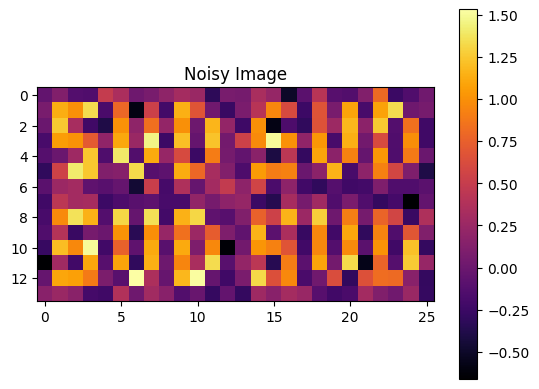

In [ ]:
np.random.seed(12345)

# Duplicate the image
Ad = np.block([[A, A], [A, A]])

# Add Gaussian noise
noise = np.random.normal(0, 0.25, Ad.shape)
A_with_noise = Ad + noise

# Color ramp values
ramp2 = ['#CFFEDA0', '#FFFFFF', '#F0F0F0', '#BDBDBD', '#636363', '#000000', '#3182BD']

# Display the noisy image as a heatmap
plt.imshow(A_with_noise, cmap='inferno', interpolation='nearest')
plt.colorbar()
plt.title('Noisy Image')
plt.show()


### Aproximación de bajo rango a una imagen
Para poder recuperar una imagen afectada por ruido, debemos en primer lugar convertir la imagen a blanco y negro, ya que SVD se trabaja es sobre matrices numéricas y de esta forma se facilita el análisis ya que la información sobre el color se reduce a una sola dimensión de intensidad. Posteriormente se debe aplicar una aproximación de bajo rango mediante la descomposición en valores singulares

Para esta aproximación se trabaja con una imagen ampliada que se construye duplicando cuatro veces la imagen original, añadiendo ruido gaussiano aleatorio con desviación estándar equivalente al 25% del rango dinámico de los datos, esto para poder obtener suficiente ruido para observar el efecto del filtrado, el cual al 25% del rango, es perceptible en el mapa de calor y afecta la reconstrucción visual

Ahora bien, para eliminar el ruido, se deben calcular los valores singulares de la matriz que en este caso llamaremos $A_n$ que representan la imagen ruidosa en blanco y negro, esta toma la forma de

$$ A_n = U \Sigma V^T $$

En el que:

* $U$ es una matriz ortogonal cuyas columnas forman una base ortonormal para el espacio de filas de $A_n$
* $\Sigma$ es una matriz diagonal que contiene los valores singulares de $A_n$, ordenados de mayor a menor
* $V^T$ es la matriz traspuesta de una matriz ortogonal cuyas filas forman una base ortonormal del espacio de columnas de $A_n$


En este caso se busca que los valores singulares más grandes sean la estructura principal de la imagen, mientras que los valores singulares más pequeños sean aquellos asociados al ruido. Por lo que, conservando solo los primeros $k$ valores singulares, sea prosible construir una aproximación de bajo rango que elimine la mayor parte del ruido, sin perder la forma visual de la imagen original

El siguiente código, implementa SVD sobre la imagen ruidosa para poder analizar las reconstrucciones de diferentes rangos

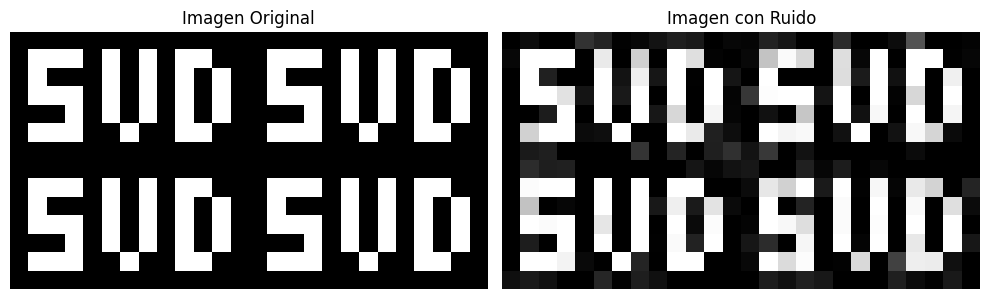

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. Definir la imagen original
# ==========================================================
A = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# ==========================================================
# 2. Ampliar la imagen (duplicar 4 veces)
# ==========================================================
An = np.block([[A, A],
               [A, A]])

# ==========================================================
# 3. Agregar ruido gaussiano
# ==========================================================
np.random.seed(12345)  # Para reproducibilidad
noise_std = 0.1  # desviación estándar del ruido
noise = np.random.normal(loc=0, scale=noise_std, size=An.shape)
A_noisy = An + noise

# ==========================================================
# 4. Visualización de la imagen original y con ruido
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

images = [An, A_noisy]
titles = ["Imagen Original", "Imagen con Ruido"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# ==========================================================
# 1. Ampliar la imagen original duplicando 4 veces
# ==========================================================
An = np.block([[A, A],
               [A, A]])

# ==========================================================
# 2. Calcular la SVD (descomposición en valores singulares)
# ==========================================================
U, S, VT = np.linalg.svd(An, full_matrices=False)

# ==========================================================
# 3. Mostrar resultados
# ==========================================================
print("Matriz U:\n")
print(U)

print("\n" + "-"*70 + "\n")

print("Vector de valores singulares Σ (redondeado a 3 decimales):\n")
print(np.round(S, 3))

print("\n" + "-"*70 + "\n")

print("Matriz V^T:\n")
print(VT)


Matriz U:

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [-3.64750091e-01  1.93499744e-01  2.94633813e-16  5.49920640e-01
  -1.64628401e-01 -6.04552844e-02 -3.65637666e-01  2.24990781e-01
  -2.03497987e-01  5.20213392e-01 -1.68278885e-16  1.52645482e-16
   0.00000000e+00  0.00000000e+00]
 [-2.78270583e-01 -3.00100638e-01 -5.00000000e-01 -1.51947404e-01
  -2.43756181e-01  4.72374891e-02  2.73969687e-01  4.54564042e-02
   5.23326824e-01  3.83108315e-01 -1.74013346e-16 -4.96449491e-18
   0.00000000e+00  0.00000000e+00]
 [-3.78143729e-01 -1.06850365e-01 -5.61577843e-15 -3.75881356e-02
   5.86666389e-01 -2.29316378e-02 -2.89825698e-01 -6.22169557e-01
   1.25880709e-01  1.11956662e-01  2.33239850e-17  2.98809693e-17
   0.00000000e+00  0.00000000e+00]
 [-2.78270583e-01 -3.00100638e-01  5.00000000e-01 -1.5194

El código anterior arrojó que los valores singulares de la matriz son:
$$\Sigma = [9.576, \ 4.35, \ 2.0 \ 1.853, \ 1.391, \ 0.0 \ 0.0, \ 0.0, \ 0.0, \ 0.0, \ 0.0, \ 0.0, \ 0.0, \ 0.0,]$$
Ya con estos datos los podemos graficar

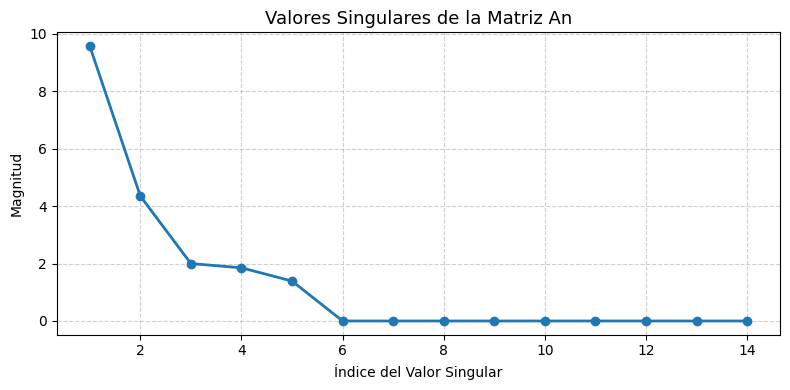

Rango máximo de A: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular la descomposición SVD
U, S, VT = np.linalg.svd(An, full_matrices=False)

# Graficar los valores singulares
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(S) + 1), S, 'o-', linewidth=2, markersize=6)
plt.title('Valores Singulares de la Matriz An', fontsize=13)
plt.xlabel('Índice del Valor Singular')
plt.ylabel('Magnitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mostrar el rango de la matriz
rango = np.linalg.matrix_rank(An)
print(f"Rango máximo de A: {rango}")

Luego de construir la matriz $A_n$ duplicando la imagen original en bloques y añadirle ruido gaussiano aleatorio, aplicamos la descomposición en valores singulares (SVD) para estudiar su estructura interna. Esta técnica nos permite separar la información relevante de la imagen de las componentes asociadas al ruido o a la redundancia, identificando cuáles modos capturan la estructura visual principal y cuáles aportan poco o nada a la reconstrucción


Al realizar la SVD de $A_n$, se obtuvieron los valores singulares del paso anterior. Estos valores muestran claramente que solo las cinco primeras componentes tienen magnitud significativa, mientras que el resto son prácticamente cero o numéricamente despreciables. La caída abrupta en la magnitud de los valores singulares indica que, pese al ruido introducido, la estructura esencial de la imagen se concentra en los primeros cinco modos

El cálculo del rango numérico mediante confirma que $Rango \ A_n = 5$. Esto significa que la imagen ruidosa puede representarse como una combinación lineal de solo cinco vectores base significativos; los demás no aportan información relevante y, por tanto, pueden eliminarse sin comprometer la estructura global

Desde la perspectiva del análisis de imágenes, los cinco primeros valores singulares capturan la información visual esencial, mientras que los valores menores reflejan ruido aleatorio, que son pequeñas distorsiones o variaciones poco relevantes. Por ello, al aplicar una reconstrucción de bajo rango utilizando únicamente los valores singulares principales, podemos mejorar la claridad de la imagen y reducir el ruido no deseado, manteniendo intacta su estructura fundamental

Formalmente, si denotamos la aproximación de rango $k$ como

$$A_{n,k}= \sum_{i=1}^{k} \sigma_i U_i V_i^T $$

Siguiendo con el Teorema de Eckart–Young–Mirsky, $A_{n,k}$ es la mejor aproximación de rango $k$ a $A_n$ en el sentido de la norma de Frobenius. Esto garantiza que, al elegir los $k$ valores singulares más grandes, conservamos la mayor parte de la estructura visual de la imagen mientras descartamos componentes que representan ruido o variaciones menores

En nuestro caso, se observa que una aproximación de rango $k=3$ permite reconstruir de manera clara las formas y patrones principales de la imagen, capturando la mayor parte de su energía visual, mientras que el incremento a $k=5$ recupera la imagen prácticamente exacta. Por lo tanto, la elección de $k$ puede ajustarse según el equilibrio deseado entre reducción de ruido y preservación de información visualr, siendo $k=3$ suficiente para una reconstrucción visualmente coherente y $k=5$ para una recuperación completa sin pérdida de detalle

### Reconstrucción de imagen con ruido

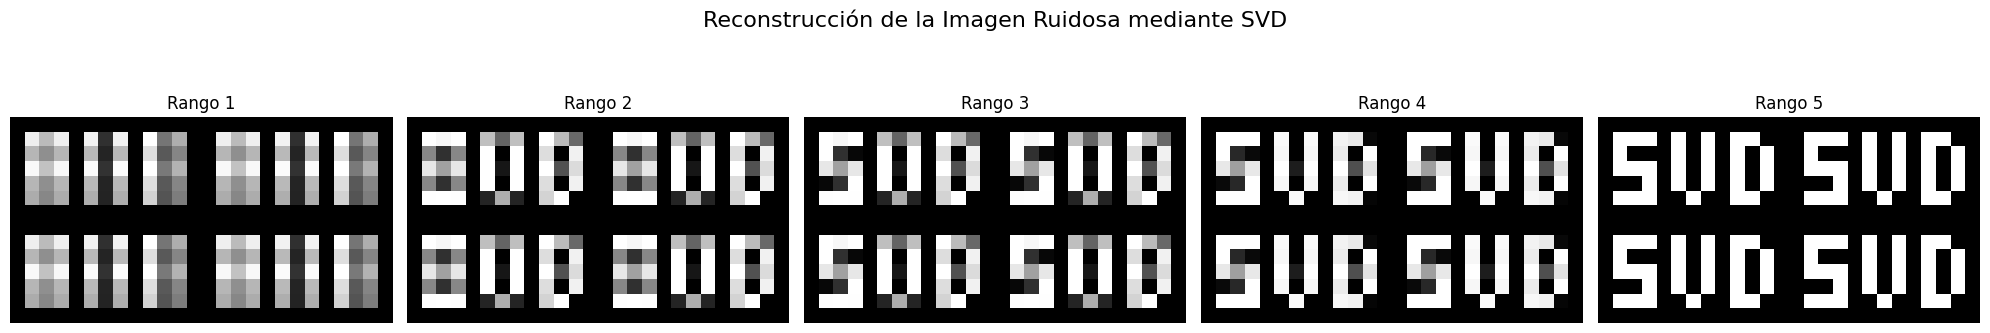

Mejor aproximación obtenida con rango k = 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Se asume que ya se ha calculado la SVD de la matriz A_with_noise
# U, S, VT = np.linalg.svd(A_with_noise, full_matrices=False)

ks = range(1, 6)  # Rangos del 1 al 5
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

min_mse, best_k = float('inf'), None

for i, k in enumerate(ks):
    # Reconstrucción de rango k
    Ak = sum(S[j] * np.outer(U[:, j], VT[j, :]) for j in range(k))

    # Error cuadrático medio respecto a la imagen original ampliada
    mse = np.mean((Ak - An) ** 2)

    # Selección del mejor rango según el menor error
    if mse < min_mse:
        min_mse, best_k = mse, k

    # Mostrar reconstrucción
    axes[i].imshow(Ak, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Rango {k}")
    axes[i].axis('off')

plt.suptitle("Reconstrucción de la Imagen Ruidosa mediante SVD", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Mejor aproximación obtenida con rango k = {best_k}")

Al aplicar la descomposición SVD sobre la imagen con ruido y reconstruirla progresivamente para distintos valores de $k$, se observa cómo las componentes singulares más importantes recuperan la estructura visual principal, mientras que las de menor magnitud tienden a incorporar ruido o redundancia

* Rango 1: la reconstrucción es muy borrosa, ya que solo se conserva la dirección de máxima varianza. Se capturan las formas globales, pero se pierden los detalles finos

* Rangos 2 y 3: comienzan a distinguirse los contornos y patrones estructurales de la imagen, aunque todavía hay presencia de ruido

* Rango 4: la reconstrucción mejora significativamente, las letras y bordes son más definidos y el ruido se reduce notablemente

* Rango 5: se obtiene una imagen casi indistinguible de la original. El ruido es mínimo y los detalles se preservan casi por completo


Con esto se pudo demostrar la capacidad de la descomposición en valores singulares para realizar una filtración de ruido conservando la información esencial. Al retener únicamente las componentes singulares de mayor peso (de bajo rango), se logra una reconstrucción más limpia y nítida, eliminando las fluctuaciones aleatorias del ruido. En este caso, el valor óptimo encontrado fue $k = {best_k}$, que representa el punto de equilibrio entre la calidad visual y la complejidad del modelo